# Trabajo Práctico Integrador

## Port Log - Sprint 1

## Integrantes del grupo:

> Obtener el número de grupo de la pestaña del aula de "Trabajos Prácticos"
>
> Entrega UN SOLO integrante del grupo, debe ser siempre el mismo.
>
> Utilizar UN ÚNICO repositorio de github por grupo.

* Hector Oviedo
* Nombre y apellido
* ...

## Repositorio GITHUB

Especificar en la siguiente línea cual es la url para acceder al repositorio del grupo.



https://github.com/HectorOviedoM/Port_Log-Grupo_16.git




## Consideraciones Generales e Importantes

- Desarrollo base: Los puntos solicitados son la base del trabajo práctico. Es posible la ampliación sin restricciones del mismo.
- Para el traceo se deben agregar 1 [secrets](https://drlee.io/how-to-use-secrets-in-google-colab-for-api-key-protection-a-guide-for-openai-huggingface-and-c1ec9e1277e0) para la utilización de github.
  - GITHUB_TOKEN
- Organización del Notebook:
  - Agregar antes del ejercicio 01 una celda donde se importan todas librerías necesarias.
  - Utilizar un título para cada celda y escribir cada funcionalidad en una celda con título.
- La defensa es individual.
- Los grupos deben mantenerse a lo largo del trabajo integrador.
- La opción `DESACTIVAR_GIT_PUSH` solo será utilizada por los profesores.

## Versionado y Trabajo en Equipo


- Control de Versiones: Utilizar herramientas de versionado
- Colaboradores: Brindar acceso al repositorio a las siguientes cuentas:
  - lcd-had141@ugr.edu.ar
  - fpasinato@ugr.edu.ar
- La descripción del commit debe ser con el siguiente formato `"Día X: \<comentario del commit\>"`
- Changelog: Cada ejercicio/punto del trabajo práctico es considerado como un día distinto de trabajo. Debe quedar constancia en un archivo CHANGELOG.md de los cambios generados cada día. El changelog debe escribirse de tal forma que lo primero que se observe es el último cambio realizado, de esta forma apenas se abre el archivo se pueden leer los últimos cambios realizados. La forma de escritura debe ser un encabezado entre corchetes [Ejercicio X] y luego debajo los cambios realizado como bullets.
- El archivo README.md debe contener el sprint en el que nos encontramos y debe contener:
  - El objetivo.
  - La introducción y el contexto del sprint de trabajo.

## Criterios de evaluación

- Funcionalidad: el código debe ejecutar sin errores al dar "Ejecutar todo" (Ctrl+F9). Validar con Runtime -> Restart session and run all antes de entregar.
- Claridad: código organizado, nombres descriptivos, comentarios solo donde corresponde (funciones, clases, métodos). No se admite `git add .`.
- Estilo: [type hints](https://docs.python.org/3/library/typing.html), [pep8](https://peps.python.org/pep-0008/).

- Herramientas: librerías vistas en la cursada. Sin gdrive ni herramientas alternativas.

## Condiciones de Entrega
- Archivo `.ipynb`, ejecutado y con datos precargados, sobre copia de la plantilla original manteniendo la nomenclatura del nombre.
- Canal: aula virtual. Correo a lcd-had141@ugr.edu.ar solo si el plazo finalizó. No se aceptan enlaces.
- Los trabajos que no cumplan con los requisitos no serán tomados en cuenta como nota final. Solo serán corregidos y evaluados con nota para la devolución correspondiente. Se considera incumplimiento a:
  - Entregas fuera de término.
  - Trabajos que no se entreguen sobre la plantilla de trabajo estipulada.
  - Trabajos que no se ejecuten completos (que contengan errores intermedios al dar "Ejecutar todo").

---



# Objetivo

Aplicar conocimientos de versionado, organización y análisis exploratorio de datos con pandas sobre un dataset real de operaciones portuarias.

## Introducción y Contexto del problema

### Sprint 1

El Puerto Fluvial de Rosario es uno de los complejos portuarios más importantes de América del Sur, siendo el principal punto de exportación de granos y derivados de la Argentina. Diariamente ingresan y egresan decenas de buques de distintas banderas con cargas de diverso tipo.

El sistema de registro de movimientos portuarios fue migrado recientemente desde un sistema heredado de los años '90. Ese sistema acumuló durante décadas inconsistencias de formato en fechas, matrículas de buques y valores numéricos fuera de rango, generando registros que no pueden incorporarse directamente al nuevo sistema.

Nuestro equipo fue contratado para analizar y depurar los datos del sistema antiguo.

Descargar el dataset [port_movements](https://raw.githubusercontent.com/HAD141/datasets/refs/heads/main/TrabajosPracticos/port_log/port_movements.csv)  

`https://raw.githubusercontent.com/HAD141/datasets/refs/heads/main/TrabajosPracticos/port_log/port_movements.csv`

---

In [61]:
#@title Agregamos variables de entorno y secrets
import os
from google.colab import userdata

HOOKS="/tmp/.git-templates/hooks"

GITHUB_TOKEN = userdata.get('GITHUB_TOKEN')
try:
  DESACTIVAR_GIT_PUSH = bool(userdata.get('DESACTIVAR_GIT_PUSH'))
except userdata.SecretNotFoundError:
  DESACTIVAR_GIT_PUSH = False
os.environ['DESACTIVAR_GIT_PUSH'] = str(DESACTIVAR_GIT_PUSH)
os.environ['HOOKS'] = HOOKS

In [62]:
#@title Creación del hook para que durante la corrección no se realicen modificaciones al repositorio
%%bash
mkdir -p $HOOKS
cat << EOF > $HOOKS/pre-push
#!/bin/sh
if [ "$DESACTIVAR_GIT_PUSH" = "'True'" ] || [ "$DESACTIVAR_GIT_PUSH" = "True" ]; then
    echo "[GIT HOOK - WARNING] Pushes are disabled for this repository."
    exit 1
fi
EOF

chmod +x $HOOKS/pre-push

In [63]:
#@title Posicionarse en directorio de trabajo y agregar la siguiente configuración a git
if DESACTIVAR_GIT_PUSH:
  !git config --global core.hooksPath {HOOKS}

In [64]:
#@title Importaciones

In [65]:
from pathlib import Path
import pandas as pd
import re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Ejercicio 01

> Puntos: 1

Inicialización y configuración de la herramienta de versionado sobre la rama `Sprint_1`.

La estructura de directorios es:

```
├── port_log
│   ├── data
│   │   ├── interim    (datasets procesados en pasos intermedios)
│   │   │   ├── plots
│   │   ├── processed  (datasets finales para otra aplicación)
│   │   ├── raw        (datasets en crudo)
│   ├── reports        (resúmenes estadísticos generados)
```

In [66]:
#@title crear el arbol de carpetas
!mkdir -p port_log/data/raw
!mkdir -p port_log/data/interim/plots
!mkdir -p port_log/data/processed
!mkdir -p port_log/reports

In [67]:
#@title verificar que se haya creado bien la estructura de carpetas
!find port_log -type d | sort

port_log
port_log/data
port_log/data/interim
port_log/data/interim/plots
port_log/data/processed
port_log/data/raw
port_log/reports


In [68]:
#@title Posicionarse en directorio de trabajo y agregar la siguiente configuración a git
if DESACTIVAR_GIT_PUSH:
  !git config --global core.hooksPath {HOOKS}

## Ejercicio 02

> Puntos: 1

- Descargar el dataset raw y almacenarlo en `port_log/data/raw/port_movements.csv`.


In [69]:

#@title Ejercicio 02 — descargar dataset raw
URL_RAW = "https://raw.githubusercontent.com/HAD141/datasets/refs/heads/main/TrabajosPracticos/port_log/port_movements.csv"
PATH_RAW = Path("port_log/data/raw/port_movements.csv")

def descargar_dataset_raw(url: str, destino: Path) -> pd.DataFrame:
    """Descarga el CSV, lo guarda en destino y lo retorna como DataFrame."""
    destino.parent.mkdir(parents=True, exist_ok=True)
    df = pd.read_csv(url)
    df.to_csv(destino, index=False)
    print(f"Guardado en {destino} — {df.shape[0]} filas x {df.shape[1]} columnas")
    return df

df_raw = descargar_dataset_raw(URL_RAW, PATH_RAW)

Guardado en port_log/data/raw/port_movements.csv — 1500 filas x 15 columnas


- Mostrar las 5 primeras y las 5 últimas filas en una única salida.


In [70]:
#@title primeras y últimas 5 filas
# head, tail y concat devuelven DataFrame; por eso se pueden unir con concat
pd.concat([df_raw.head(5), df_raw.tail(5)])

,movimiento_id,buque_id,matricula,radar_id,muelle,tipo_carga,origen,fecha_ingreso,hora_ingreso,fecha_egreso,hora_egreso,tonelaje_declarado,velocidad_ingreso,velocidad_maxima_muelle,estado_despacho
0,MOV-00001,B-008,MSC-GENOVA,R-05,MUELLE-B,TRIGO,MONTEVIDEO,2023-04-24,13:02,2023-04-24,10:55 PM,3874.34,6.3,10,DESPACHADO
1,MOV-00002,B-025,MAERSK-LIMA,R-06,MUELLE-C,HARINA,SANTA FE,2020-06-10,17:18,2020-06-12,7:05,1856.07,10.2,12,RECHAZADO
2,MOV-00003,B-011,ZIM-NORTE,R-04,MUELLE-B,MINERALES,ROTTERDAM,32/13/2021,21:20,2021-03-26,19:01,6711.61,11.7,15,EN_REVISION
3,MOV-00004,B-038,NaN,R-06,MUELLE-B,MAIZ,HAMBURG,2023-07-09,5:50,2023-07-11,1:20,5086.61,6.0,10,DESPACHADO
4,MOV-00005,B-017,ONE-PLATA,R-03,MUELLE-E,SOJA,VALPARAISO,2024-05-13,16:58,2024-05-13,2:16,6166.47,16.2,15,PENDIENTE
1495,MOV-01496,B-019,HAPAG-SUR,R-01,MUELLE-A,MAIZ,SHANGHAI,2022-07-07,4:19,2022-07-08,23:19,4692.60,11.6,15,DESPACHADO
1496,MOV-01497,B-035,YANG-ESTE,R-01,muelle e!!,SOJA,SANTA FE,2021-06-30,20:29,2021-07-02,NaN,4523.07,6.5,10,DESPACHADO
1497,MOV-01498,B-012,ONE-PLATA,R-08,MUELLE-D,ACEITE,HAMBURG,2022-11-08,13:35,2022-11-10,02:45 AM,4845.04,9.3,12,EN_REVISION
1498,MOV-01499,B-026,PIL-SANTA,R-06,MUELLE-B,TRIGO,VALPARAISO,2021-06-27,20:40,2021-06-30,10:20 PM,4197.51,10.1,15,RECHAZADO
1499,MOV-01500,B-008,@#$%,R-08,MUELLE-C,ACEITE,SHANGHAI,2023-09-24,6:15,2023-09-25,21:53,5811.38,15.4,10,EN_REVISION


- Analizar tipos de datos e indicar cuáles columnas requieren conversión.


In [71]:
# Análisis general del dataset
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   movimiento_id            1500 non-null   object 
 1   buque_id                 1500 non-null   object 
 2   matricula                1444 non-null   object 
 3   radar_id                 1435 non-null   object 
 4   muelle                   1500 non-null   object 
 5   tipo_carga               1500 non-null   object 
 6   origen                   1500 non-null   object 
 7   fecha_ingreso            1500 non-null   object 
 8   hora_ingreso             1500 non-null   object 
 9   fecha_egreso             1500 non-null   object 
 10  hora_egreso              1466 non-null   object 
 11  tonelaje_declarado       1431 non-null   float64
 12  velocidad_ingreso        1418 non-null   float64
 13  velocidad_maxima_muelle  1500 non-null   int64  
 14  estado_despacho         

A simple vista gracias a las funciones .info() y .head() se puede analizar que las principales columnas que requieren conversión son:

* `fecha_ingreso` y `fecha_egreso`: son de tipo texto (object) y tienen formatos inconsistentes o erróneos, por ejemplo, el registro 2 tiene 32/13/2021, un día y mes imposible. Se deben parsear a tipo fecha (datetime64) para detectar errores y realizar cálculos temporales.

* `hora_ingreso` y `hora_egreso`: también son de tipo texto y se mezclan formatos de 24 horas con formato AM/PM de 12 horas. Deben unificarse y convertirse a formato de tiempo normalizado de 24 horas.

* `matricula` y `muelle`: son de tipo texto, lo cual es correcto, pero necesitan limpieza de cadenas de texto.

In [72]:
df_raw.describe()

,tonelaje_declarado,velocidad_ingreso,velocidad_maxima_muelle
count,1431.000000,1418.000000,1500.000000
mean,6460.527680,16.014316,12.350000
std,12699.275719,24.468070,2.022431
min,-4898.960000,0.200000,10.000000
25%,4106.280000,9.925000,10.000000
50%,5011.860000,12.100000,12.000000
75%,5891.480000,14.200000,15.000000
max,147434.290000,199.300000,15.000000


La función *.describe()* muestra las estadísiticas generales de las columnas numéricas y se puede analizar que tanto `tonelaje_declarado` como `velocidad_ingreso` tienen valores atípicos muy extremos que necesitan ser transformados o limpiados.

- Contar los valores nulos y mostrarlos ordenados de mayor a menor.


In [73]:
# Contar valores nulos por columna y ordenar de mayor a menor
nulos = df_raw.isna().sum().sort_values(ascending=False)

print(nulos)

velocidad_ingreso          82
tonelaje_declarado         69
radar_id                   65
estado_despacho            58
matricula                  56
hora_egreso                34
movimiento_id               0
origen                      0
tipo_carga                  0
muelle                      0
buque_id                    0
fecha_egreso                0
hora_ingreso                0
fecha_ingreso               0
velocidad_maxima_muelle     0
dtype: int64


- Calcular y mostrar el porcentaje de valores correctos por cada columna. Por ejemplo, si en una fila de fechas tengo una letra, entonces la contabilizo como valor incorrecto. Los valores nulos son considerados como valores incorrectos.

  Generar una única salida y debe tener el siguiente formato:
```
Completitud del dataset:
 - nombre_columna_1: XX.XX% completa
 - nombre_columna_2: XX.XX% completa
 - ...
```

In [74]:
total_filas = len(df_raw)

# Función para las fechas
def es_fecha_valida(val):
    if pd.isna(val):
        return False
    dt = pd.to_datetime(val, errors="coerce", format="mixed")
    return pd.notna(dt)

# Función para las horas
def es_hora_valida(val):
    if pd.isna(val):
        return False
    val_str = str(val).strip()
    patron = r"^([0-1]?[0-9]|2[0-3]):[0-5][0-9](\s*([AP]\.?M\.?))?$"
    return bool(re.match(patron, val_str, re.IGNORECASE))

# Función para la limpieza de texto
def es_texto_valido(val):
    if pd.isna(val):
        return False
    val_str = str(val).strip()
    return not bool(re.search(r"[@#$%!]", val_str))


# Diccionario con reglas de validación por columna
validaciones = {
    "movimiento_id": es_texto_valido,
    "buque_id": es_texto_valido,
    "matricula": es_texto_valido,
    "radar_id": es_texto_valido,
    "muelle": es_texto_valido,
    "tipo_carga": es_texto_valido,
    "origen": es_texto_valido,
    "fecha_ingreso": es_fecha_valida,
    "hora_ingreso": es_hora_valida,
    "fecha_egreso": es_fecha_valida,
    "hora_egreso": es_hora_valida,
    "tonelaje_declarado": lambda x: pd.notna(x),
    "velocidad_ingreso": lambda x: pd.notna(x),
    "velocidad_maxima_muelle": lambda x: pd.notna(x),
    "estado_despacho": es_texto_valido,
}

print("Completitud del dataset:")

for col in df_raw.columns:
    func_valida = validaciones.get(col, lambda x: pd.notna(x))
    correctos = df_raw[col].apply(func_valida).sum()
    porcentaje = (correctos / total_filas) * 100
    print(f" - {col}: {porcentaje:.2f}% completa")

Completitud del dataset:
 - movimiento_id: 100.00% completa
 - buque_id: 100.00% completa
 - matricula: 90.53% completa
 - radar_id: 95.67% completa
 - muelle: 95.20% completa
 - tipo_carga: 100.00% completa
 - origen: 100.00% completa
 - fecha_ingreso: 96.47% completa
 - hora_ingreso: 93.53% completa
 - fecha_egreso: 97.53% completa
 - hora_egreso: 87.67% completa
 - tonelaje_declarado: 95.40% completa
 - velocidad_ingreso: 94.53% completa
 - velocidad_maxima_muelle: 100.00% completa
 - estado_despacho: 96.13% completa


## Ejercicio 03

> Puntos: 2

Utilizando Pandas, realizar la limpieza y normalización de datos:

- Normalizar fechas de ingreso y egreso al formato `YYYY-MM-DD`. Las fechas inválidas deben completarse con `1900-01-01`.

  Mostrar las 10 primeras fechas de ingreso.



In [75]:
# Normalizar fecha_ingreso
fecha_ing_dt = pd.to_datetime(df_raw['fecha_ingreso'], errors='coerce', format='mixed')
df_raw['fecha_ingreso'] = fecha_ing_dt.dt.strftime('%Y-%m-%d').fillna('1900-01-01')

# Normalizar fecha_egreso
fecha_egr_dt = pd.to_datetime(df_raw['fecha_egreso'], errors='coerce', format='mixed')
df_raw['fecha_egreso'] = fecha_egr_dt.dt.strftime('%Y-%m-%d').fillna('1900-01-01')

# Mostrar las 10 primeras fechas de ingreso
df_raw[['fecha_ingreso', 'fecha_egreso']].head(10)

,fecha_ingreso,fecha_egreso
0,2023-04-24,2023-04-24
1,2020-06-10,2020-06-12
2,1900-01-01,2021-03-26
3,2023-07-09,2023-07-11
4,2024-05-13,2024-05-13
5,2022-11-25,2022-11-27
6,2022-08-14,2022-08-15
7,2022-02-15,2022-02-16
8,1900-01-01,2022-04-07
9,2022-01-26,2022-01-28


- Normalizar las horas con el formato de 24hs. Las horas inválidas deben completarse con `00:00`.

  Mostrar los datos de las 10 primeras horas inválidas.


In [76]:
# Función para intentar convertir una hora a datetime con formato 24hs
def normalizar_hora(val):
    if pd.isna(val):
        return None
    val_str = str(val).strip()
    dt = pd.to_datetime(val_str, format="%H:%M", errors="coerce")
    if pd.isna(dt):
        dt = pd.to_datetime(val_str, format="%I:%M %p", errors="coerce")
    return dt.dt.strftime("%H:%M") if pd.notna(dt) else None


# Identificar horas inválidas antes de imputar
invalidas_ingreso = pd.to_datetime(
    df_raw["hora_ingreso"], format="%H:%M", errors="coerce"
).isna() & pd.to_datetime(
    df_raw["hora_ingreso"], format="%I:%M %p", errors="coerce"
).isna()
invalidas_egreso = pd.to_datetime(
    df_raw["hora_egreso"], format="%H:%M", errors="coerce"
).isna() & pd.to_datetime(
    df_raw["hora_egreso"], format="%I:%M %p", errors="coerce"
).isna()

# Mostrar los datos de las 10 primeras horas inválidas
df_invalidas = df_raw[invalidas_ingreso | invalidas_egreso][
    ["hora_ingreso", "hora_egreso"]
].head(10)
print("10 primeras horas inválidas encontradas:")
display(df_invalidas)

# Normalizar y rellenar horas inválidas con '00:00'
hora_ing_dt = pd.to_datetime(
    df_raw["hora_ingreso"], format="%H:%M", errors="coerce"
).fillna(
    pd.to_datetime(df_raw["hora_ingreso"], format="%I:%M %p", errors="coerce")
)
df_raw["hora_ingreso"] = hora_ing_dt.dt.strftime("%H:%M").fillna("00:00")

hora_egr_dt = pd.to_datetime(
    df_raw["hora_egreso"], format="%H:%M", errors="coerce"
).fillna(
    pd.to_datetime(df_raw["hora_egreso"], format="%I:%M %p", errors="coerce")
)
df_raw["hora_egreso"] = hora_egr_dt.dt.strftime("%H:%M").fillna("00:00")


10 primeras horas inválidas encontradas:


,hora_ingreso,hora_egreso
9,AB:CD,13:30
22,4:17,39:54:00
25,0:48,sin dato
31,AB:CD,5:25
35,21:13,24:00:00
49,20:32,00:25 XM
51,1:55,26:11:00
53,2:36,____
60,AB:CD,12:29
62,9:45,sin dato



- Calcular y agregar la columna `duracion_horas`: tiempo transcurrido entre `fecha_ingreso`+`hora_ingreso` y `fecha_egreso`+`hora_egreso`. Cuando el cálculo no sea posible (fechas inválidas en alguno de los extremos) asignar `pd.NA`.

  Mostrar los datos de las 10 primeras duraciones.


In [77]:
#Función para asignar NA a fechas inválidas
def calcular_duracion(row):
    if (
        row["fecha_ingreso"] == "1900-01-01"
        or row["fecha_egreso"] == "1900-01-01"
    ):
        return pd.NA

    try:
        # Combina fecha y hora
        inicio = pd.to_datetime(f"{row['fecha_ingreso']} {row['hora_ingreso']}")
        fin = pd.to_datetime(f"{row['fecha_egreso']} {row['hora_egreso']}")
        # Calcula diferencia en horas
        diferencia = (fin - inicio).total_seconds() / 3600.0
        # Si el egreso ocurre antes del ingreso o da negativo, tratarlo como inconsistencia si aplica
        return diferencia if diferencia >= 0 else pd.NA
    except Exception:
        return pd.NA

# Aplicar el cálculo a cada fila
df_raw["duracion_horas"] = df_raw.apply(calcular_duracion, axis=1)

# Mostrar los datos de las 10 primeras duraciones
df_raw[
    [
        "fecha_ingreso",
        "hora_ingreso",
        "fecha_egreso",
        "hora_egreso",
        "duracion_horas",
    ]
].head(10)

,fecha_ingreso,hora_ingreso,fecha_egreso,hora_egreso,duracion_horas
0,2023-04-24,13:02,2023-04-24,22:55,9.883333
1,2020-06-10,17:18,2020-06-12,07:05,37.783333
2,1900-01-01,21:20,2021-03-26,19:01,<NA>
3,2023-07-09,05:50,2023-07-11,01:20,43.5
4,2024-05-13,16:58,2024-05-13,02:16,<NA>
5,2022-11-25,14:07,2022-11-27,01:06,34.983333
6,2022-08-14,23:03,2022-08-15,02:13,3.166667
7,2022-02-15,00:24,2022-02-16,23:15,46.85
8,1900-01-01,03:56,2022-04-07,03:18,<NA>
9,2022-01-26,00:00,2022-01-28,13:30,61.5



- Normalizar matrículas: quitar caracteres especiales y pasar a mayúsculas. Cuando la matrícula no sea válida completar con `pd.NA`.

  Mostrar los datos de las 10 últimas.


In [78]:
def normalizar_matricula(val):
    if pd.isna(val):
        return pd.NA
    val_str = str(val).upper().strip()
    # Si contiene únicamente caracteres especiales (como @#$%), invalida
    if not any(c.isalnum() for c in val_str):
        return pd.NA
    # Elimina caracteres especiales manteniendo letras, números y espacios
    limpio = re.sub(r"[^A-Z0-9\-\s]", "", val_str).strip()
    return limpio if limpio else pd.NA

# Aplicar normalización a la columna matricula
df_raw["matricula"] = df_raw["matricula"].apply(normalizar_matricula)

# Mostrar los datos de las 10 últimas filas
df_raw[["matricula"]].tail(10)

,matricula
1490,CMA-LITORAL
1491,ONE-PARANA
1492,EVERGREEN-02
1493,<NA>
1494,YANG-MING
1495,HAPAG-SUR
1496,YANG-ESTE
1497,ONE-PLATA
1498,PIL-SANTA
1499,<NA>



- Normalizar muelles: quitar caracteres especiales y pasar a mayúsculas.

  Mostrar los datos de los 10 primeros.


In [79]:
def normalizar_muelle(val):
    if pd.isna(val):
        return pd.NA
    # Convierte a mayúscula y quita espacios en los extremos
    val_str = str(val).upper().strip()
    # Elimina caracteres especiales
    limpio = re.sub(r"[^A-Z0-9\s\-]", "", val_str).strip()
    # Unifica espacios múltiples a uno solo si los hubiera
    limpio = re.sub(r"\s+", " ", limpio)
    return limpio if limpio else pd.NA

# Aplicar normalización a la columna muelle
df_raw["muelle"] = df_raw["muelle"].apply(normalizar_muelle)

# Mostrar los datos de los 10 primeros muelles normalizados
df_raw[["muelle"]].head(10)

,muelle
0,MUELLE-B
1,MUELLE-C
2,MUELLE-B
3,MUELLE-B
4,MUELLE-E
5,MUELLE-B
6,MUELLE-D
7,MUELLE-D
8,MUELLE-E
9,MUELLE-E



- Eliminar filas con nulos en columnas críticas. Comentar el porque se seleccionaron esas columnas como críticas.

  Mostrar las columnas críticas y la cantidad de filas eliminadas para esa columna.
```
Las columnas críticas son:
 - nombre_columna: XXX
 - ...
```


In [80]:
# Las siguienes columnas son necesarias porque identifican el movimiento, calculan la velocidad y deciden si existe una infracción:
columnas_criticas = [
    "movimiento_id",
    "matricula",
    "fecha_ingreso",
    "fecha_egreso",
    "hora_ingreso",
    "hora_egreso",
    "tonelaje_declarado",
    "velocidad_ingreso",
    "velocidad_maxima_muelle",
]

filas_antes = len(df_raw)
for columna in columnas_criticas:
    filas_antes_columna = len(df_raw)
    df_raw = df_raw.dropna(subset=[columna])
    filas_eliminadas = filas_antes_columna - len(df_raw)
    print(f"{columna}: {filas_eliminadas} filas eliminadas")

print("Columnas críticas:", columnas_criticas)

movimiento_id: 0 filas eliminadas
matricula: 91 filas eliminadas
fecha_ingreso: 0 filas eliminadas
fecha_egreso: 0 filas eliminadas
hora_ingreso: 0 filas eliminadas
hora_egreso: 0 filas eliminadas
tonelaje_declarado: 63 filas eliminadas
velocidad_ingreso: 73 filas eliminadas
velocidad_maxima_muelle: 0 filas eliminadas
Columnas críticas: ['movimiento_id', 'matricula', 'fecha_ingreso', 'fecha_egreso', 'hora_ingreso', 'hora_egreso', 'tonelaje_declarado', 'velocidad_ingreso', 'velocidad_maxima_muelle']



- Detectar y eliminar outliers en `tonelaje_declarado` y `velocidad_ingreso`. Para esto utilizaremos los métodos [IQR](https://www.geeksforgeeks.org/machine-learning/interquartile-range-to-detect-outliers-in-data/) y [Z-score](https://www.geeksforgeeks.org/data-science/z-score-in-statistics/).

  Comparar y justificar el método elegido en un comentario dentro de la celda.

  Mostrar las columnas críticas y la cantidad de filas eliminadas para esa columna.
```
Las columnas críticas son:
 - nombre_columna: XXX
 - ...
```

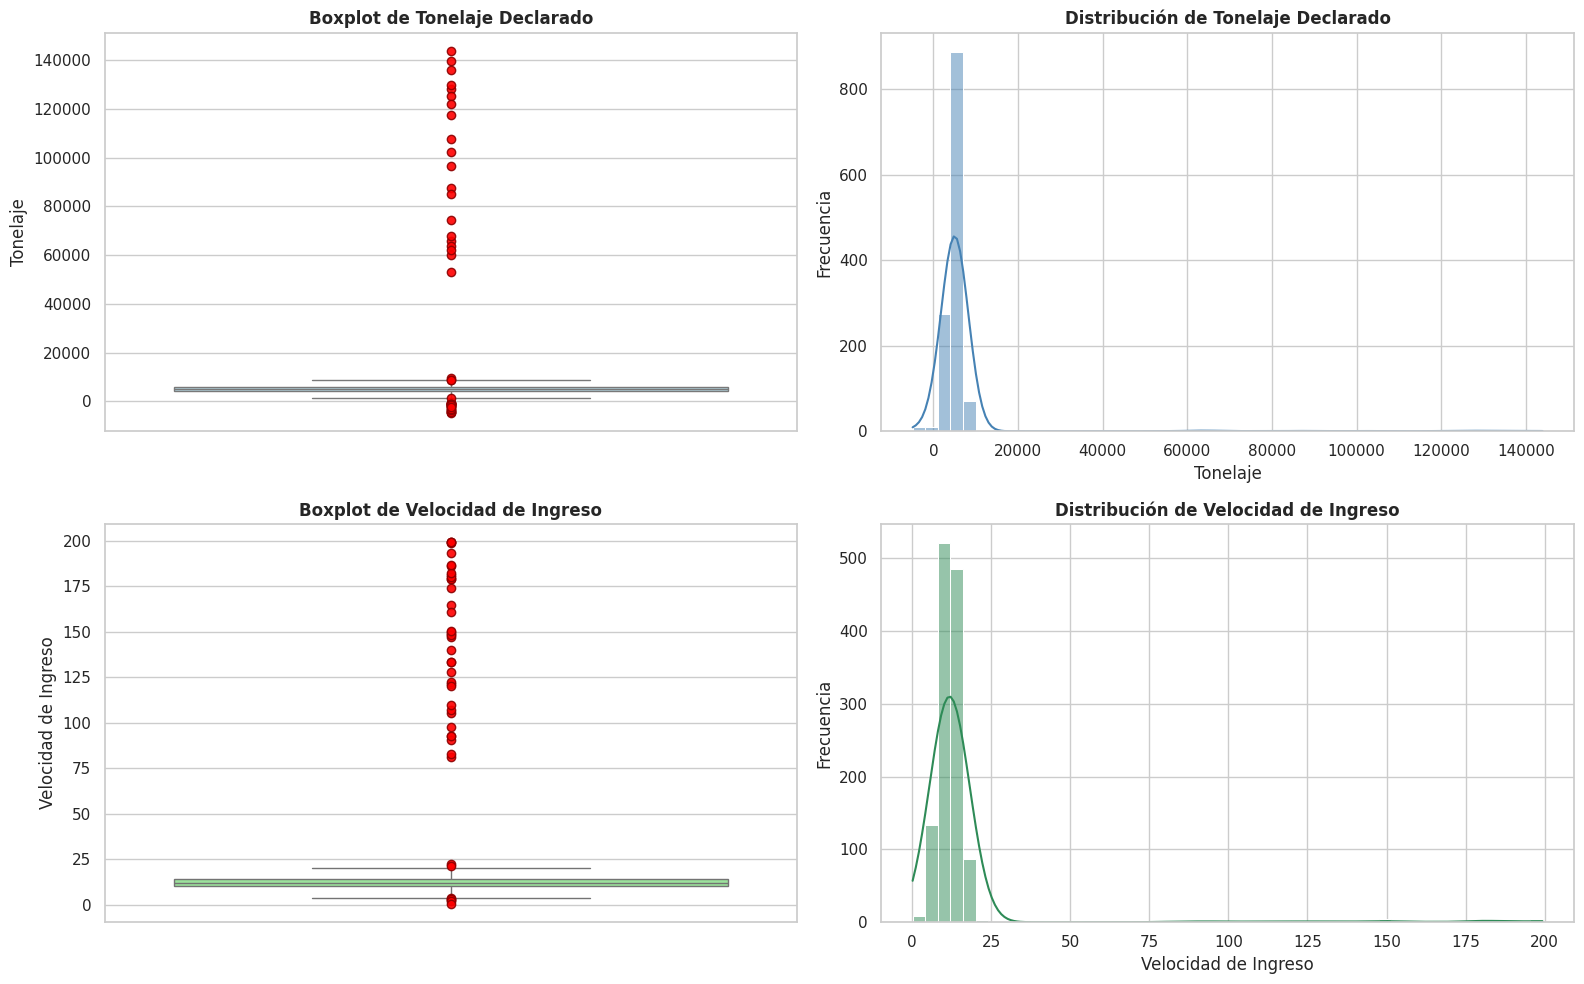

In [81]:
# Configurar grid de 2 filas x 2 columnas
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# --- VARIABLE 1: TONELAJE DECLARADO ---
# Boxplot con escala completa para ver el outlier de 147k y el negativo
sns.boxplot(data=df_raw, y='tonelaje_declarado', ax=axes[0, 0], color='lightblue',
            flierprops=dict(marker='o', markerfacecolor='red', markeredgecolor='darkred', alpha=0.9))
axes[0, 0].set_title("Boxplot de Tonelaje Declarado", fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel("Tonelaje")

# Histograma + Densidad para ver la forma de la masa de datos
sns.histplot(data=df_raw, x='tonelaje_declarado', ax=axes[0, 1], kde=True, color='steelblue', bins=50)
axes[0, 1].set_title("Distribución de Tonelaje Declarado", fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel("Tonelaje")
axes[0, 1].set_ylabel("Frecuencia")


# --- VARIABLE 2: VELOCIDAD DE INGRESO ---
# Boxplot con escala completa (el outlier llega casi a 200)
sns.boxplot(data=df_raw, y='velocidad_ingreso', ax=axes[1, 0], color='lightgreen',
            flierprops=dict(marker='o', markerfacecolor='red', markeredgecolor='darkred', alpha=0.9))
axes[1, 0].set_title("Boxplot de Velocidad de Ingreso", fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel("Velocidad de Ingreso")

# Histograma + Densidad
sns.histplot(data=df_raw, x='velocidad_ingreso', ax=axes[1, 1], kde=True, color='seagreen', bins=50)
axes[1, 1].set_title("Distribución de Velocidad de Ingreso", fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel("Velocidad de Ingreso")
axes[1, 1].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

In [82]:
# Los gráficos demuestran que existen valores atípicos extremos y que usar el método Z score no es adecuado porque los datos no tienen una distribución normal y la presencia de estos extremos distorsiona la media y la desviación estándar, afectando la precisión del límite. En cambio, utilizar el método IQR permite calcular correctamente los extremos ya que se basa en medianas y cuartiles.

def eliminar_outliers_iqr(df, columna):
    q1 = df[columna].quantile(0.25)
    q3 = df[columna].quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    filas_validas = df[columna].between(limite_inferior, limite_superior)
    return df[filas_validas].copy(), (~filas_validas).sum()

for columna in ["tonelaje_declarado", "velocidad_ingreso"]:
    df_raw[columna] = pd.to_numeric(df_raw[columna], errors="coerce")
    df_raw, filas_eliminadas = eliminar_outliers_iqr(df_raw, columna)
    print(f"{columna}: {filas_eliminadas} outliers eliminados")

tonelaje_declarado: 44 outliers eliminados
velocidad_ingreso: 42 outliers eliminados




- Crear columna `exceso_velocidad_real`: diferencia entre `velocidad_ingreso` y `velocidad_maxima_muelle`. Mostrar los datos de las 10 primeras matrículas con su valor.


In [83]:
# Exceso real: diferencia entre la velocidad registrada y el límite del muelle.
df_raw["exceso_velocidad_real"] = (
    df_raw["velocidad_ingreso"] - df_raw["velocidad_maxima_muelle"]
)
print(df_raw[["matricula", "exceso_velocidad_real"]].head(10))

      matricula  exceso_velocidad_real
0    MSC-GENOVA                   -3.7
1   MAERSK-LIMA                   -1.8
2     ZIM-NORTE                   -3.3
4     ONE-PLATA                    1.2
5     PIL-SANTA                   -0.1
6     ZIM-DELTA                   -2.4
7     ZIM-DELTA                   -2.9
9   MAERSK-LIMA                   -0.5
11   ONE-PARANA                    1.2
12    ZIM-DELTA                    1.1



- Crear columna `exceso_velocidad`: diferencia entre `velocidad_ingreso` y `velocidad_maxima_muelle` más un 5% de tolerancia.

  Mostrar los datos de las 10 primeras matrículas con su valor.


In [84]:
# Se considera una tolerancia del 5% sobre la velocidad máxima permitida.
limite_con_tolerancia = df_raw["velocidad_maxima_muelle"] * 1.05
df_raw["exceso_velocidad"] = (
    df_raw["velocidad_ingreso"] - limite_con_tolerancia
)
print(df_raw[["matricula", "exceso_velocidad"]].head(10))

      matricula  exceso_velocidad
0    MSC-GENOVA             -4.20
1   MAERSK-LIMA             -2.40
2     ZIM-NORTE             -4.05
4     ONE-PLATA              0.45
5     PIL-SANTA             -0.70
6     ZIM-DELTA             -3.00
7     ZIM-DELTA             -3.40
9   MAERSK-LIMA             -1.00
11   ONE-PARANA              0.70
12    ZIM-DELTA              0.50



- Eliminar filas sin infracción según `exceso_velocidad`.

```
Se eliminaron X filas sin infracción.
```


In [85]:
# Solo se conservan los movimientos que superan el límite con tolerancia.
filas_antes = len(df_raw)
df_raw = df_raw[df_raw["exceso_velocidad"] > 0].copy()
print(f"Se eliminaron {filas_antes - len(df_raw)} filas sin infracción.")

Se eliminaron 740 filas sin infracción.



- Guardar dataset limpio en `port_log/data/interim/port_movements.csv`.


In [86]:
PATH_INTERIM = Path("port_log/data/interim/port_movements.csv")
PATH_INTERIM.parent.mkdir(parents=True, exist_ok=True)
df_raw.to_csv(PATH_INTERIM, index=False)
print(f"Dataset limpio guardado en {PATH_INTERIM}")

Dataset limpio guardado en port_log/data/interim/port_movements.csv



- Exportar el resumen estadístico rápido de pandas en `port_log/reports/summary_sprint1.csv`.

In [87]:
PATH_SUMMARY = Path("port_log/reports/summary_sprint1.csv")
df_raw.describe(include="all").to_csv(PATH_SUMMARY)
print(f"Resumen guardado en {PATH_SUMMARY}")

Resumen guardado en port_log/reports/summary_sprint1.csv


## Ejercicio 04

> Puntos: 2

Definir una clase `PortAnalyzer` que:

- Reciba el DataFrame limpio en `__init__` y encapsule los datos correctamente.

- Implemente los siguientes métodos:

  - **`top_infractores(n: int) -> pd.DataFrame`**: ranking de las `n` matrículas con más infracciones.
  
    Retorna un DataFrame ordenado de mayor a menor, índice desde 1, columnas `matricula` y `cantidad`.

  - **`infracciones_por_turno() -> pd.DataFrame`**: agrupa infracciones en turnos del día según la hora de ingreso:
    - Madrugada: 00:00–05:59
    - Mañana: 06:00–11:59
    - Tarde: 12:00–17:59
    - Noche: 18:00–23:59
    
    Retorna un DataFrame con columnas `turno` y `cantidad`, ordenado de mayor a menor.

  - **`exceso_promedio() -> float`**: Retorna el exceso de velocidad promedio calculado sobre la columna `exceso_velocidad_real`.

  - **`exceso_promedio_tolerancia() -> float`**: Retorna el exceso de velocidad promedio calculado sobre la columna `exceso_velocidad`.

  - **`infracciones_por_muelle() -> pd.DataFrame`**: Retorna un DataFrame con la cantidad de infracciones por muelle, ordenado alfabéticamente con las columnas `muelle` y `cantidad`.

  - **`infractores_por_tipo_carga() -> pd.DataFrame`**: Retorna un DataFrame con la cantidad de infracciones agrupadas por `tipo_carga`, de mayor a menor con las columnas `tipo_carga` y `cantidad`.



- Crear el objeto `PortAnalyzer` e invocar cada método en celdas separadas.

## Ejercicio 05

> Puntos: 2

Responder cada punto con un gráfico. Cada gráfico se debe mostrar en el notebook. Todos deben tener título, etiquetas en los ejes y leyenda cuando corresponda.

- **Top 10 matrículas más reincidentes** en barras verticales, de mayor a menor.

  Exportar: `port_log/data/interim/plots/top_infractores.jpg`.



- **Total de infracciones por turno del día** (Madrugada / Mañana / Tarde / Noche) en gráfico de torta.

  Exportar: `port_log/data/interim/plots/turnos.jpg`.



- **Total de infracciones por mes** en barras horizontal, ordenado de mayor a menor.

  Exportar: `port_log/data/interim/plots/meses.jpg`.



- **Histograma del exceso de velocidad real** con curva de densidad (KDE) superpuesta.

  Exportar: `port_log/data/interim/plots/distribucion_exceso.jpg`.



- **Exceso de velocidad promedio por muelle** en barras horizontal, ordenado de mayor a menor.

  Exportar: `port_log/data/interim/plots/exceso_por_muelle.jpg`.



- **Comparación de infracciones con fecha válida vs fecha inválida (`1900-01-01`)** en barras simple.

  Exportar: `port_log/data/interim/plots/fechas_invalidas.jpg`.

## Ejercicio 06

> Puntos: 1

Responder las siguientes preguntas con el dataset limpio:

- ¿Qué porcentaje de infracciones provienen de registros con fecha inválida?
```
El porcentaje de infracciones con fecha inválida es XX.XX%
```



- ¿Qué porcentaje de infracciones provienen de registros con hora inválida?
```
El porcentaje de infracciones con hora inválida es XX.XX%
```



- ¿Cuál es el tipo de carga más frecuente en infracciones y qué porcentaje representa?
```
El tipo de carga más frecuente es XXXX con XX.XX%
```



- ¿Cuál es el origen más frecuente entre los buques infractores?
```
El origen más frecuente entre infractores es XXXX con XX registros.
```



- ¿Cuál es la duración promedio de estadía en muelle de los buques infractores?
```
La duración promedio de estadía de buques infractores es XX.XX horas.
```

## Ejercicio 07

> Puntos: 1

Redactar una conclusión que incluya:

- Evaluación de la calidad del dataset heredado: porcentaje de registros descartados y tipos de error más frecuentes.
- Patrones de infracción detectados: ¿en qué turnos, muelles y tipos de carga se concentran?
- Reflexión sobre el impacto de incorporar estos datos sin limpieza previa al nuevo sistema.
- Al menos una propuesta concreta de mejora para el proceso de captura de datos en el puerto.

Guardar la conclusión en `port_log/reports/conclusion.md`

---

# CHECKS

`De aquí en adelante solo ejecutar`

## Visualizar la rama actual

In [59]:
!git status

fatal: not a git repository (or any of the parent directories): .git


## Visualizar el contenido de cada commit

In [60]:
!git --no-pager log --name-status Sprint_1

fatal: not a git repository (or any of the parent directories): .git
